# Dataset Curation 

some of our dft calculations could have gone wrong. The way to filter this is through the E-V curves for each sample. 

# 
- input : non curated bs
- output: curated bs regarding ev curves

TODO: bopio and bopcal needed for featurizer ! separate package for bopfox ?

## check ev-curves for goodness

In [14]:
import sys
#sys.path.insert(0,'/home/storage/fortimtb/DatasetsML/Tools/')
sys.path.insert(0,'/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
dataset = 'Cr-Co-W/'
from Tools.DatasetTools.getEVcurves import *
from Tools.DatasetTools.GetFaultyEVcurves import *
from BopFoxFeaturizer.Featurizer import Featurizer
import pickle


import os

In [15]:
PBS = pd.read_pickle(os.path.join(dataset, 'ParsedBriefsummary.pkl'))

## Investigate ev-curves

In [16]:
evcurvesloc = os.path.join(dataset,'evcurves.json' )
if not os.path.exists(evcurvesloc):
    EV = Evcurves(atoms=['Cr','Co','W'], dataset = dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
    EV.load_evcurves(PBS.index, deltaks = PBS['deltak'], encuts = PBS['encut'])
    EV.evcurves.to_json(evcurvesloc)
EVcurves = pd.read_json(evcurvesloc, typ='series') 
goodness, fiteos, r2  = get_goodness(EVcurves)         
#plot_curves (goodness, EVcurves, 'multipage_fitted_curves.pdf')
#plot_curves (invert_goodness(goodness), EVcurves, 'multipage_bad_curves.pdf')

100%|██████████| 1834/1834 [00:02<00:00, 731.06it/s]


In [17]:
goodness

Co_pv6W_sv6.C14-BBA.FM                 {'xc=PBE-PAW.E=400.dk=0.020': True}
Co_pv6W_sv6.C14-BBA.NM                 {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv6W_sv2.D0_19-A3B.FM               {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv6W_sv2.D0_19-A3B.NM               {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM     {'xc=PBE-PAW.E=400.dk=0.020': True}
                                                      ...                 
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM      {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM      {'xc=PBE-PAW.E=400.dk=0.020': True}
Co_pv13W_sv16.chi-ABAB.NM              {'xc=PBE-PAW.E=400.dk=0.020': True}
Co_pv13W_sv16.chi-ABAB.FM             {'xc=PBE-PAW.E=400.dk=0.020': False}
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.NM     {'xc=PBE-PAW.E=400.dk=0.020': True}
Length: 1834, dtype: object

In [18]:
indexofgoodsamples = pd.Index([theindex for theindex, thecurve in goodness.items() if True in thecurve.values()])
GoodBS = PBS.loc[indexofgoodsamples]
BadBS = PBS.loc[PBS.index.difference(indexofgoodsamples)]

## Remove extra magnetic sampling

First feature to remove from this dataset is the list of samples used form ferrimagnetic phase sampling. This subset is not in the current interest and might bring problems so we remove from datastet.

In [19]:
GoodBS = GoodBS.loc[~GoodBS.index.str.contains('\..*[UD]+$') ]

In [20]:
GoodBS.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
Index: 1701 entries, Co_pv6W_sv6.C14-BBA.FM to Cr_pv16Co_pv4W_sv10.sigma-CBAAC.NM
Columns: 19 entries,  to num_atoms
dtypes: float64(4), int64(1), object(14)
memory usage: 265.8+ KB


## Obtain some info from indexes

In [21]:
Features = Featurizer(GoodBS)

## translate structures to their bases

In [22]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    GoodBS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=GoodBS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [23]:
GoodBS[''] = Target_Class

In [24]:
GoodBS = GoodBS.rename(columns ={'':'Phase'})

# Save for later use 

In [25]:
curatedbs = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')
with open(curatedbs, 'wb') as pkl:
    pickle.dump(GoodBS, pkl)

# some E-V curves, good and bad

In [26]:
sample_bad = EVcurves[BadBS.index].dropna().sample(n=5)

In [27]:
sample_bad

Cr_pv10Co_pv14.C36-BABAB.FM          {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv4Co_pv20.C36-BBABB.FM                                                          {}
Co_pv9W_sv4.mu-AAABB.FM              {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv16Co_pv4W_sv4.C36-BACAA.FM      {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv8Co_pv20W_sv2.sigma-CBABB.FM    {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
dtype: object

In [28]:
goodness[sample_bad.index]

Cr_pv10Co_pv14.C36-BABAB.FM          {'xc=PBE-PAW.E=400.dk=0.020': False}
Cr_pv4Co_pv20.C36-BBABB.FM                                             {}
Co_pv9W_sv4.mu-AAABB.FM              {'xc=PBE-PAW.E=400.dk=0.020': False}
Cr_pv16Co_pv4W_sv4.C36-BACAA.FM      {'xc=PBE-PAW.E=400.dk=0.020': False}
Cr_pv8Co_pv20W_sv2.sigma-CBABB.FM    {'xc=PBE-PAW.E=400.dk=0.020': False}
dtype: object

In [29]:
sample_bad_r2 = r2[sample_bad.index]

In [30]:
sample_bad_fit = fiteos[sample_bad.index]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


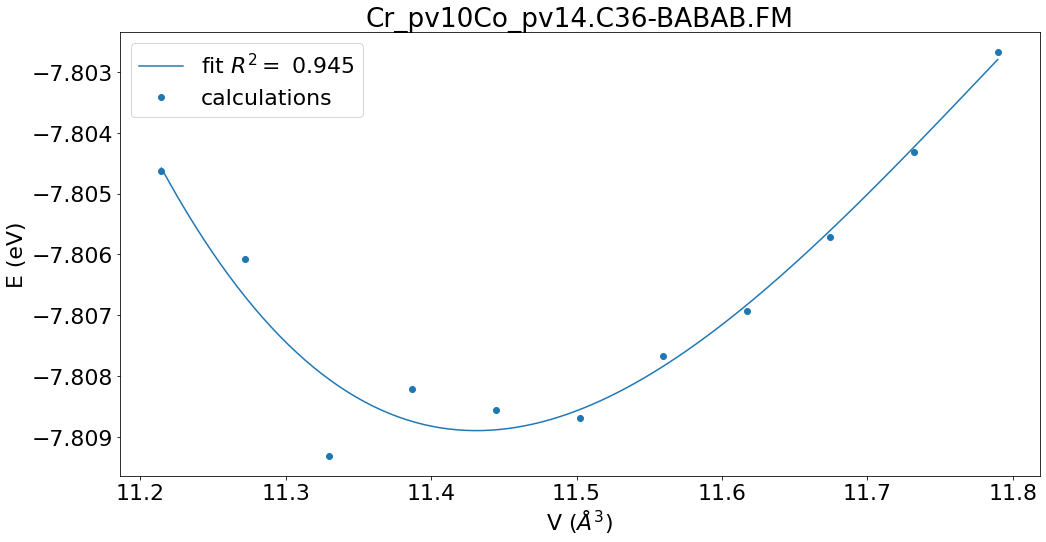

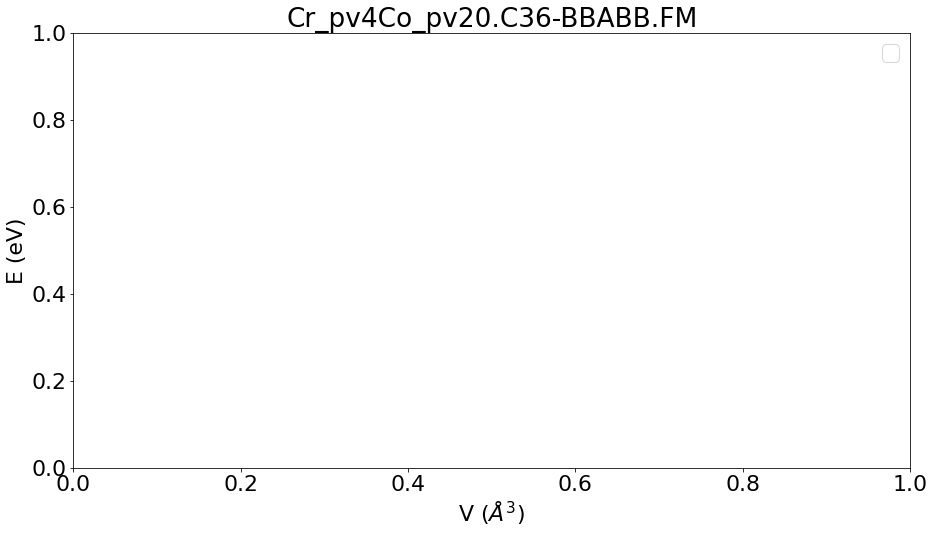

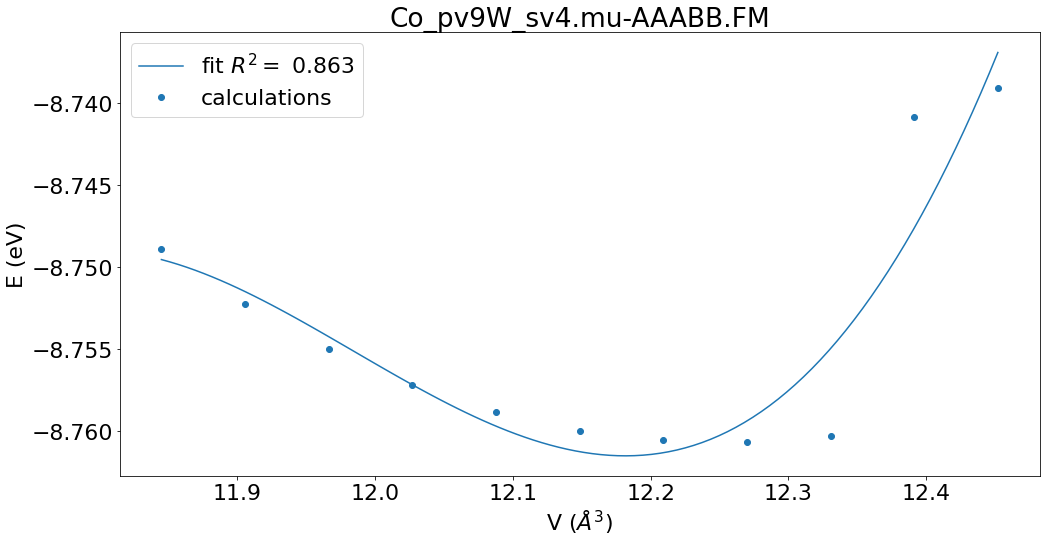

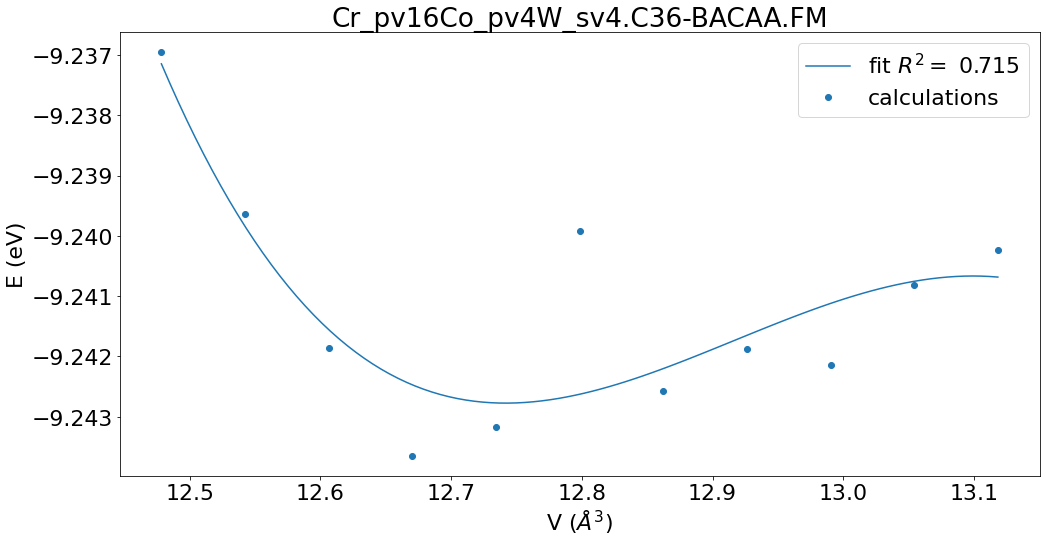

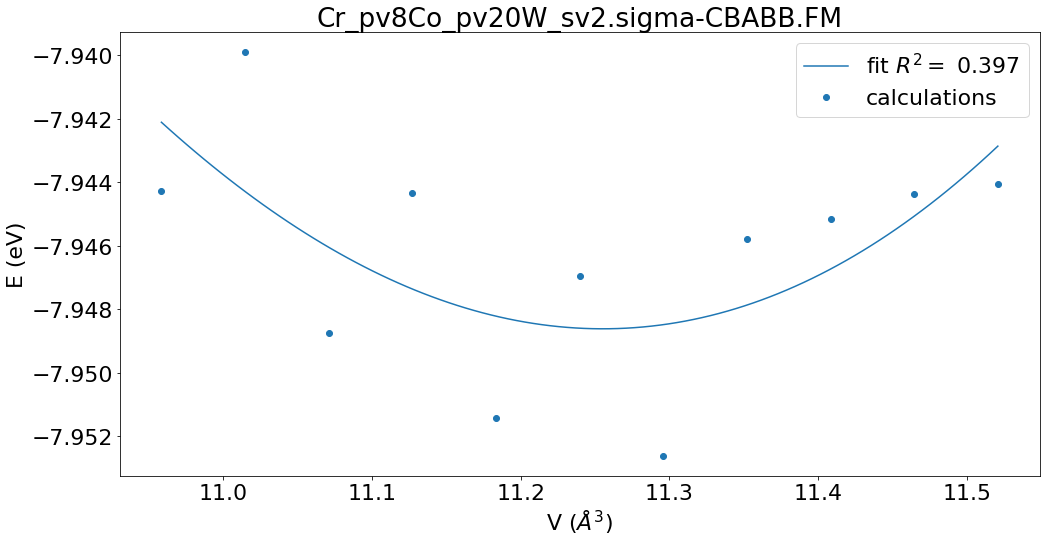

In [31]:
figurecollection, axcollection  = plot_curves(sample_bad, sample_bad_fit, sample_bad_r2)